# 📊 Project 4: Income Prediction Using Categorical Data
Here we load the data from the folder which has been downloaded and uploaded with the code to the Git. Also here we load some important modules which wee need throughout this notebook.


In [40]:
# Enable autoreloading of imported modules
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The data gets loaded in its right format according to the guidelines which inlcude that the target variable needs to be formatted

$$
y =
\begin{cases}
1 & \text{if income } > \$50K \\
0 & \text{otherwise}
\end{cases}
$$.

Furthermore, one column gets dropped indefently as it will not be used within this task.


In [41]:
file_name = "adult.data"
column_names = column_names = [ #names of all columns from the data set
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "Class"
]
df = pd.read_csv(file_name, names= column_names,skipinitialspace=True)

target_variable_map = { # we map according to the task guidelines
    "<=50K": 0,
    ">50K": 1,
}

columns_to_be_dropped = [ # we drop the fnlwgt as it represents weights and we deem it as not neccessary within this task
    "fnlwgt"
]

df= df.drop(columns=columns_to_be_dropped)
df["Class"] = df["Class"].map(target_variable_map)
df

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Class
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
32557,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
32558,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
32559,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


## Identify which categorical features are low- or high-cardinality

Text


## Analyze which variables have a meaningful order (e.g., education)

Text

## Implement and compare the Encoding strategies

All encoding strategies are implemented in the project library which has been created specifically for this project.

## Minimum: Handle missing values appropriately ✅ 

## Minimum: Apply and compare at least two different encoding strategies ✅ 
In this part we compare all encoding strategies and also one costum dataset which uses the data encoding methods more strategically on each column (if its categorical).

For the setup we will load the models (ie Logistic regression and linear SVM) from the , however, the linear SVM is implemented with the target varibale having values in $\{-1,1\}$ which is not what the task guidlines require. Thus, instead mapping the values form $\{0,1\}$ to $\{-1,1\}$, we decided to adapt the model from the courselib here in the notebook accordingly.

In [42]:
import numpy as np
from courselib.models.base import TrainableModel
from courselib.models.glm import LogisticRegression

class LinearSVM(TrainableModel):

    def __init__(self, w, b, optimizer, C=10.):
        super().__init__(optimizer)
        self.w = np.array(w, dtype=float)
        self.b = np.array(b, dtype=float)
        self.C = C
    
    def loss_grad(self, X, y):
       # Compute raw model output
        output = self.decision_function(X)

        y = np.where(y == 0, -1, 1)

        # Identify margin violations: where 1 - y*h(x) > 0
        mask = (1 - y * output) > 0
        y_masked = y[mask]
        X_masked = X[mask]

        # Compute 
        if len(y_masked) > 0:
            grad_w = 2 * self.w - self.C * np.mean(y_masked[:, None] * X_masked, axis=0)
            grad_b = - self.C * np.mean(y_masked)
        else:
            grad_b = 0.0
            grad_w = 2 * self.w

        return {"w": grad_w, "b": grad_b}
    
    def decision_function(self, X):
        return X @ self.w + self.b
    
    def _get_params(self):
        return {"w": self.w, "b": self.b}

    def __call__(self, X):
        return np.where(self.decision_function(X) >= 0, 1, 0)


Also loading the optimizer we will use throughout this notebook.

In [43]:
from courselib.optimizers import GDOptimizer

optimizer = GDOptimizer(learning_rate=0.01)

### Minimum: accuracy, precision, recall ✅ 
We will load all three methods here and then use them in each case model evaluation case appropriatly. Also we will need nomralization between values as in some cases there will be a huge difference in the absolute value of variables values.

In [44]:
from courselib.utils.metrics import binary_accuracy
from courselib.utils.normalization import standardize

from projectlib.metrics import binary_precision, binary_recall # from the own added library

### One-Hot Encoding

Here we define all variables

In [53]:
k = 3

one_hot_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
]

penalty_functions = ["ridge", "lasso"]
lam =[0.0,0.001,0.005,0.01,0.02,0.05,0.1,0.2,0.5,0.7,1.]


Here we start cross validation like in the lecture

❌❌❌❌❌VERY SLOW

In [ ]:
from projectlib.splits import  data_to_numpy_transfomer
from projectlib.encoding import One_Hot_Encoder
from courselib.utils.splits import k_fold_split

df_encoded = One_Hot_Encoder(df.drop(columns=["native-country,education-num"]),column_to_be_encoded=one_hot_cols, delete_old_column = True)#########drop native country maybe not

X, Y = data_to_numpy_transfomer(df_encoded,class_column_name='Class')
X_cv, Y_cv = k_fold_split(X,Y,k=k)

acc_by_fold = {penalty: [] for penalty in penalty_functions}
prec_by_fold = {penalty: [] for penalty in penalty_functions}
rec_by_fold = {penalty: [] for penalty in penalty_functions}
metrics_history_by_fold = {penalty: [] for penalty in penalty_functions}

print("start folds")##########################
for i in range(len(X_cv)):
    
    x_train = np.concatenate(X_cv[:i] + X_cv[i+1:])
    y_train = np.concatenate(Y_cv[:i] + Y_cv[i+1:])
    x_test = X_cv[i]
    y_test = Y_cv[i]
    
    x_train = standardize(x_train)
    x_test = standardize(x_test)
    
    w = np.zeros(x_train.shape[1])
    b = 0
    
    for penalty in penalty_functions:
        
        acc_by_fold[penalty].append([])
        prec_by_fold[penalty].append([])
        rec_by_fold[penalty].append([])
        metrics_history_by_fold[penalty].append([])
        
        for l in lam:
            model = LogisticRegression(w, b, optimizer, penalty=penalty, lam=l)
            metrics_history = model.fit(x_train,y_train, num_epochs = 500, batch_size=len(x_train), compute_metrics=True, metrics_dict=metrics_dict)
            metrics_history_by_fold[penalty][-1].append(metrics_history)
            
            y_pred = model(x_test)
            
            acc_by_fold[penalty][-1].append(binary_accuracy(y_pred,y_test, class_labels=[1,0]))
            prec_by_fold[penalty][-1].append(binary_precision(y_pred,y_test))
            rec_by_fold[penalty][-1].append(binary_recall(y_pred,y_test))

start folds


KeyboardInterrupt: 

Now we plot

In [ ]:
penalties_to_plot = ["ridge","lasso"]
metric_data = [acc_by_fold, prec_by_fold, rec_by_fold]
metric_names = ["Accuracy","Precision","Recall"]

fig, axes = plt.subplots(3,2, figsize=(14,14))

for row in range(3):
    for col in range(2):
        penalty = penalties_to_plot[col]
        ax = axes[row,col]
        
        for i in range(len(metric_data[row][penalty])):
            ax.plot(lam,metric_data[row][penalty][i],ls='--', marker='o', label=f"Fold = {i}")
        
        mean_cv_metric = np.mean(np.array(metric_data[row][penalty]),axis=0)
        ax.plot(lam,mean_cv_metric, color='k', linewidth=2, marker='o', label='Mean over CV folds')
        ax.plot([],[],ls='--',color='k', label='CV folds')
        
        ax.set_xlabel(r'$\lambda$')
        ax.set_ylabel(metric_names[row])
        ax.set_title(f'{metric_names[row]} ({penalty} penalty)')
        ax.grid()
        ax.legend()
        
        best_l = lam[np.argmax(mean_cv_metric)]
        print(f"Best lambda value for {metric_names[row]} with {penalty} penalty (CV estimate): {best_l}")

plt.tight_layout()

### Ordinal Encoding

Here we define all variables

In [60]:
k = 3

cols_to_order = [
    "education",
    "workclass",
    "relationship",
    "marital-status",
    "occupation",
    "native-country"
]

categories_order = [
    [
        "Preschool",
        "1st-4th",
        "5th-6th",
        "7th-8th",
        "9th",
        "10th",
        "11th",
        "12th",
        "HS-grad",
        "Some-college",
        "Assoc-voc",
        "Assoc-acdm",
        "Bachelors",
        "Masters",
        "Prof-school",
        "Doctorate"
    ],
    [
        "Never-worked",
        "Without-pay",
        "Private",
        "State-gov",
        "Local-gov",
        "Self-emp-not-inc",
        "Federal-gov",
        "Self-emp-inc"
    ],
    [
        "Not-in-family",
        "Unmarried",
        "Other-relative",
        "Own-child",
        ["Husband","Wife"]
    ],
    [
        "Never-married",
        "Separated",
        "Divorced",
        "Widowed",
        "Married-spouse-absent",
        ["Married-civ-spouse","Married-AF-spouse"]
    ],
    [
        "Priv-house-serv",
        "Other-service",
        "Handlers-cleaners",
        "Farming-fishing",
        "Machine-op-inspct",
        "Transport-moving",
        "Adm-clerical",
        "Craft-repair",
        "Sales",
        "Tech-support",
        "Protective-serv",
        "Prof-specialty",
        "Armed-Forces",
        "Exec-managerial"
    ],
    [
        "Haiti",
        "Nicaragua",
        "Laos",
        "Honduras",
        "India",
        "Cambodia",
        "Philippines",
        "Vietnam",
        "Guatemala",
        "Iran",
        "El-Salvador",
        "Jamaica",
        "Ecuador",
        "Cuba",
        "Columbia",
        "Peru",
        "Thailand",
        "Dominican-Republic",
        "Yugoslavia",
        "Mexico",
        "China",
        "Trinadad&Tobago",
        "Hungary",
        "Poland",
        "Greece",
        "Portugal",
        "Japan",
        "Taiwan",
        "South",
        "Puerto-Rico",
        "Outlying-US(Guam-USVI-etc)",
        "Italy",
        "France",
        "England",
        "Scotland",
        "Germany",
        "Canada",
        "Hong",
        "Holand-Netherlands",
        "United-States",
        "Ireland"
    ]
]

starting_numbers = [1,1,1,1,1,1]

step_sizes = [1,1,1,1,1,1]

penalty_functions = ["ridge", "lasso"]
lam =[0.0,0.001,0.005,0.01,0.02,0.05,0.1,0.2,0.5,0.7,1.]

Here we start cross validation like in the lecture

In [62]:
from projectlib.encoding import Ordinal_Encoder
from courselib.utils.splits import k_fold_split
from projectlib.encoding import drop_rows 
drop_col = ["sex", "race"]

df_encoded = Ordinal_Encoder(drop_rows(df,["?"]).drop(columns=drop_col),column_to_be_encoded=cols_to_order, categories_order=categories_order, starting_numbers=starting_numbers, step_sizes=step_sizes)####rewrite

metrics_dict = {'accuracy': lambda y_pred,y_true: binary_accuracy(y_pred,y_true,class_labels=[1,0]),
                'precision': lambda y_pred,y_true: binary_precision(np.where(y_pred >= 0.5, 1, 0),y_true),
                'recall': lambda y_pred,y_true: binary_recall(np.where(y_pred >= 0.5, 1, 0),y_true)}

X, Y = data_to_numpy_transfomer(df_encoded,class_column_name='Class')
X_cv, Y_cv = k_fold_split(X,Y,k=k)

acc_by_fold = {penalty: [] for penalty in penalty_functions}
prec_by_fold = {penalty: [] for penalty in penalty_functions}
rec_by_fold = {penalty: [] for penalty in penalty_functions}
metrics_history_by_fold = {penalty: [] for penalty in penalty_functions}

for i in range(len(X_cv)):
    
    x_train = np.concatenate(X_cv[:i] + X_cv[i+1:])
    y_train = np.concatenate(Y_cv[:i] + Y_cv[i+1:])
    x_test = X_cv[i]
    y_test = Y_cv[i]
    
    x_train = standardize(x_train)
    x_test = standardize(x_test)
    
    w = np.zeros(x_train.shape[1])
    b = 0
    
    for penalty in penalty_functions:
        
        acc_by_fold[penalty].append([])
        prec_by_fold[penalty].append([])
        rec_by_fold[penalty].append([])
        metrics_history_by_fold[penalty].append([])
        
        for l in lam:
            model = LogisticRegression(w, b, optimizer, penalty=penalty, lam=l)
            metrics_history = model.fit(x_train,y_train, num_epochs = 500, batch_size=len(x_train), compute_metrics=True, metrics_dict=metrics_dict)
            metrics_history_by_fold[penalty][-1].append(metrics_history)
            
            y_pred = model(x_test)
            
            acc_by_fold[penalty][-1].append(binary_accuracy(y_pred,y_test, class_labels=[1,0]))
            prec_by_fold[penalty][-1].append(binary_precision(y_pred,y_test))
            rec_by_fold[penalty][-1].append(binary_recall(y_pred,y_test))

2399 out of 32561 were deleted, ie.92.63229016307852% still remain 


Here we plot

Best lambda value for Accuracy with ridge penalty (CV estimate): 0.1
Best lambda value for Accuracy with lasso penalty (CV estimate): 0.02
Best lambda value for Precision with ridge penalty (CV estimate): 1.0
Best lambda value for Precision with lasso penalty (CV estimate): 0.05
Best lambda value for Recall with ridge penalty (CV estimate): 0.0
Best lambda value for Recall with lasso penalty (CV estimate): 0.0


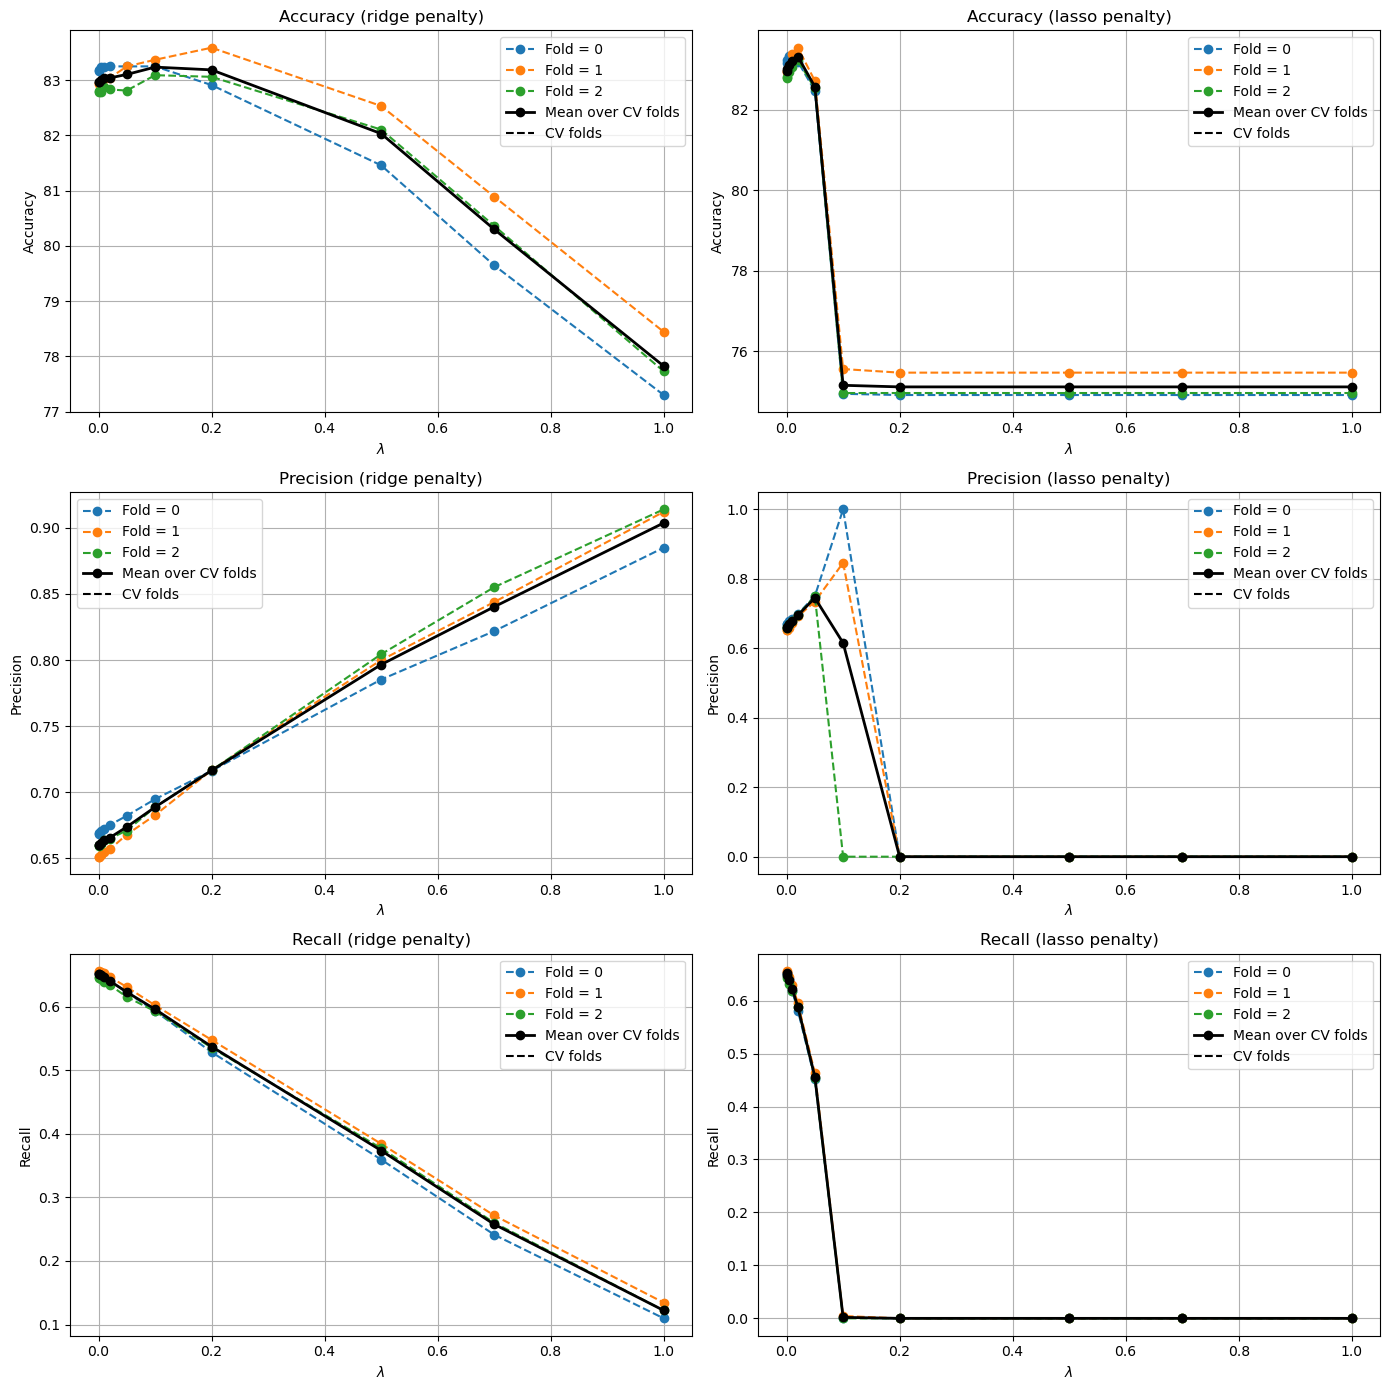

In [63]:
penalties_to_plot = ["ridge","lasso"]
metric_data = [acc_by_fold, prec_by_fold, rec_by_fold]
metric_names = ["Accuracy","Precision","Recall"]

fig, axes = plt.subplots(3,2, figsize=(14,14))

for row in range(3):
    for col in range(2):
        penalty = penalties_to_plot[col]
        ax = axes[row,col]
        
        for i in range(len(metric_data[row][penalty])):
            ax.plot(lam,metric_data[row][penalty][i],ls='--', marker='o', label=f"Fold = {i}")
        
        mean_cv_metric = np.mean(np.array(metric_data[row][penalty]),axis=0)
        ax.plot(lam,mean_cv_metric, color='k', linewidth=2, marker='o', label='Mean over CV folds')
        ax.plot([],[],ls='--',color='k', label='CV folds')
        
        ax.set_xlabel(r'$\lambda$')
        ax.set_ylabel(metric_names[row])
        ax.set_title(f'{metric_names[row]} ({penalty} penalty)')
        ax.grid()
        ax.legend()
        
        best_l = lam[np.argmax(mean_cv_metric)]
        print(f"Best lambda value for {metric_names[row]} with {penalty} penalty (CV estimate): {best_l}")

plt.tight_layout()

### Frequency Encoding

Here we define all variables

In [65]:
k =3

freq_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]

penalty_functions = ["ridge", "lasso"]
lam =[0.0,0.001,0.005,0.01,0.02,0.05,0.1,0.2,0.5,0.7,1.]

Here we start cross validation like in the lecture.

In [66]:
from projectlib.encoding import Frequency_Encoder
from courselib.utils.splits import k_fold_split

metrics_dict = {'accuracy': lambda y_pred,y_true: binary_accuracy(y_pred,y_true,class_labels=[1,0]),
                'precision': lambda y_pred,y_true: binary_precision(np.where(y_pred >= 0.5, 1, 0),y_true),
                'recall': lambda y_pred,y_true: binary_recall(np.where(y_pred >= 0.5, 1, 0),y_true)}

df_encoded = Frequency_Encoder(df,column_to_be_encoded=freq_cols, delete_old_column = True)

X, Y = data_to_numpy_transfomer(df_encoded,class_column_name='Class')
X_cv, Y_cv = k_fold_split(X,Y,k=k)

acc_by_fold = {penalty: [] for penalty in penalty_functions}
prec_by_fold = {penalty: [] for penalty in penalty_functions}
rec_by_fold = {penalty: [] for penalty in penalty_functions}
metrics_history_by_fold = {penalty: [] for penalty in penalty_functions}

for i in range(len(X_cv)):
    
    x_train = np.concatenate(X_cv[:i] + X_cv[i+1:])
    y_train = np.concatenate(Y_cv[:i] + Y_cv[i+1:])
    x_test = X_cv[i]
    y_test = Y_cv[i]
    
    x_train = standardize(x_train)
    x_test = standardize(x_test)
    
    w = np.zeros(x_train.shape[1])
    b = 0
    
    for penalty in penalty_functions:
        
        acc_by_fold[penalty].append([])
        prec_by_fold[penalty].append([])
        rec_by_fold[penalty].append([])
        metrics_history_by_fold[penalty].append([])
        
        for l in lam:
            model = LogisticRegression(w, b, optimizer, penalty=penalty, lam=l)
            metrics_history = model.fit(x_train,y_train, num_epochs = 500, batch_size=len(x_train), compute_metrics=True, metrics_dict=metrics_dict)
            metrics_history_by_fold[penalty][-1].append(metrics_history)
            
            y_pred = model(x_test)
            
            acc_by_fold[penalty][-1].append(binary_accuracy(y_pred,y_test, class_labels=[1,0]))
            prec_by_fold[penalty][-1].append(binary_precision(y_pred,y_test))
            rec_by_fold[penalty][-1].append(binary_recall(y_pred,y_test))

Here we plot.

Best lambda value for Accuracy with ridge penalty (CV estimate): 0.02
Best lambda value for Accuracy with lasso penalty (CV estimate): 0.02
Best lambda value for Precision with ridge penalty (CV estimate): 1.0
Best lambda value for Precision with lasso penalty (CV estimate): 0.05
Best lambda value for Recall with ridge penalty (CV estimate): 0.0
Best lambda value for Recall with lasso penalty (CV estimate): 0.0


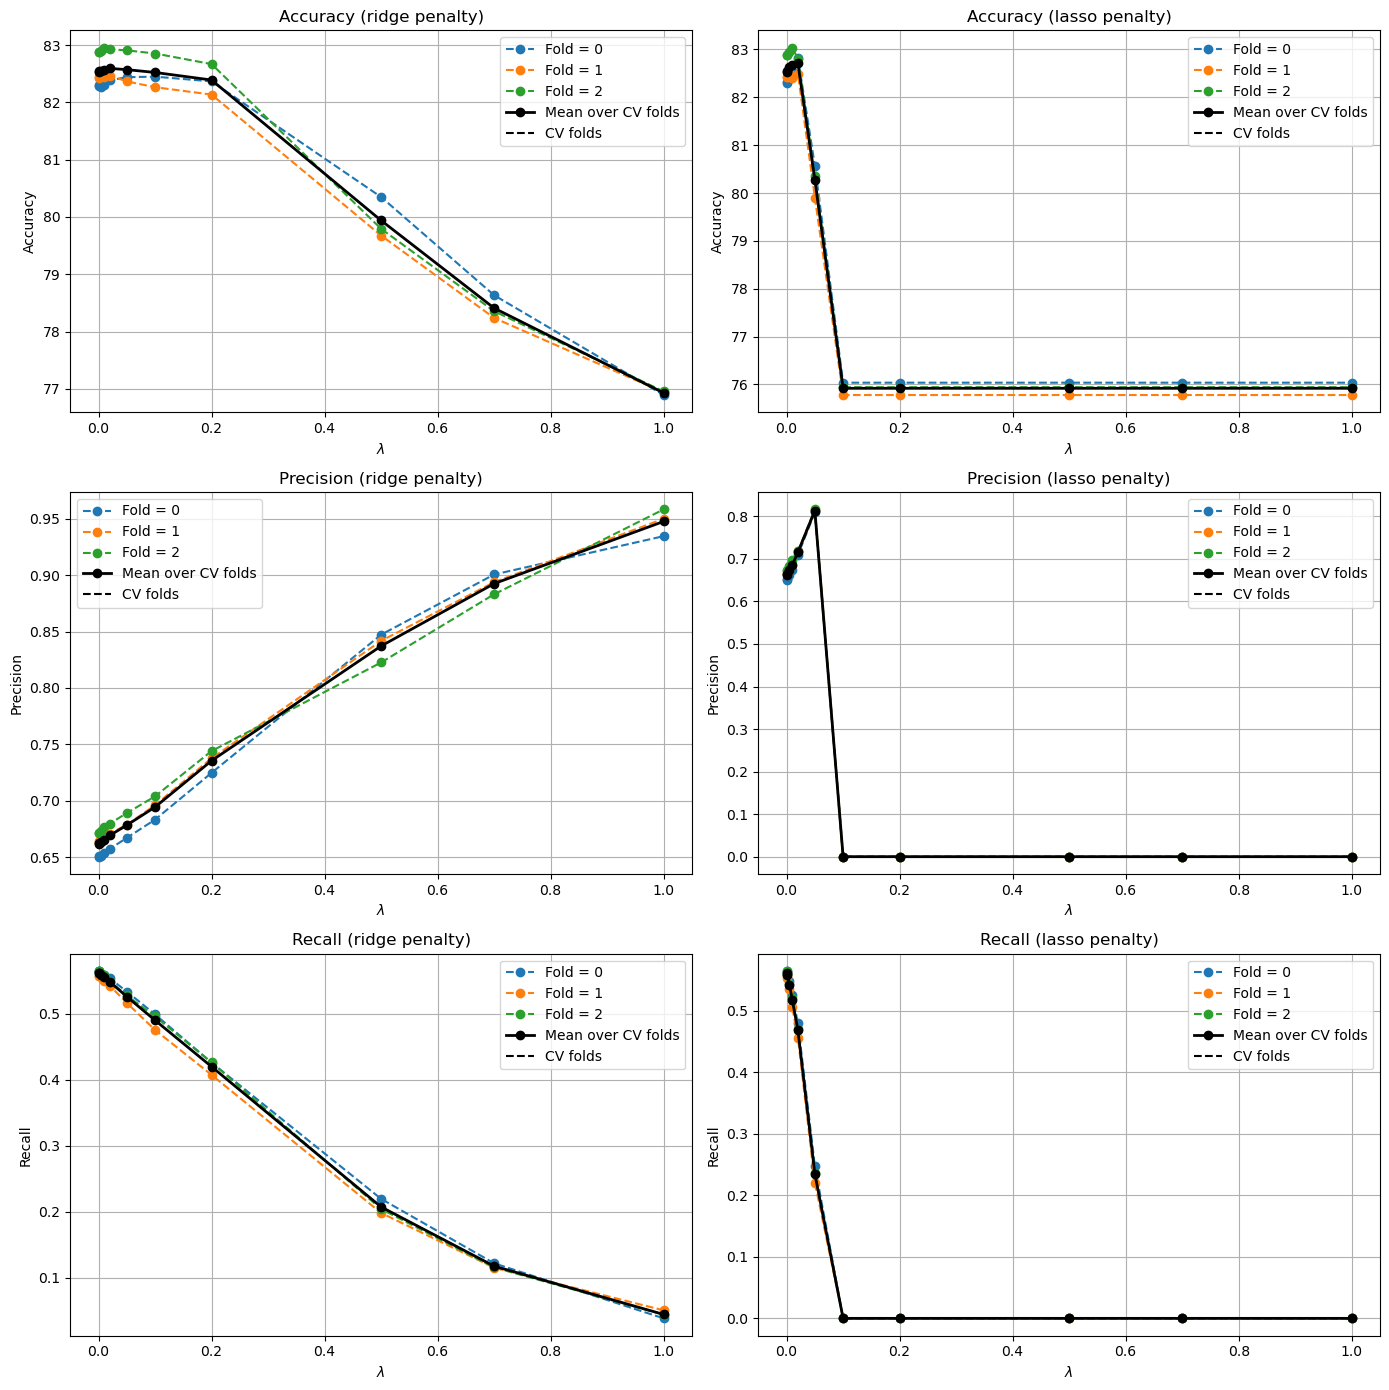

In [67]:
penalties_to_plot = ["ridge","lasso"]
metric_data = [acc_by_fold, prec_by_fold, rec_by_fold]
metric_names = ["Accuracy","Precision","Recall"]

fig, axes = plt.subplots(3,2, figsize=(14,14))

for row in range(3):
    for col in range(2):
        penalty = penalties_to_plot[col]
        ax = axes[row,col]
        
        for i in range(len(metric_data[row][penalty])):
            ax.plot(lam,metric_data[row][penalty][i],ls='--', marker='o', label=f"Fold = {i}")
        
        mean_cv_metric = np.mean(np.array(metric_data[row][penalty]),axis=0)
        ax.plot(lam,mean_cv_metric, color='k', linewidth=2, marker='o', label='Mean over CV folds')
        ax.plot([],[],ls='--',color='k', label='CV folds')
        
        ax.set_xlabel(r'$\lambda$')
        ax.set_ylabel(metric_names[row])
        ax.set_title(f'{metric_names[row]} ({penalty} penalty)')
        ax.grid()
        ax.legend()
        
        best_l = lam[np.argmax(mean_cv_metric)]
        print(f"Best lambda value for {metric_names[row]} with {penalty} penalty (CV estimate): {best_l}")

plt.tight_layout()

### Target Encoding (with CV) ✅ 
Here we implement leakage control for target encoding using cross-validation, ie we encode each fold using target statistics from other folds (not including the target of the encoded point).

It is the following to note: oringally the idea was to use `k_fold_split` as in the lecture about regularization. However, as this method was developed for numpy input/output and our encoding methods were written to handle mainly dataframes we decided to implement a new method called `k_fold_split_dataframe` which essentially does the same as `k_fold_split`, however, it hanldes dataframe inputs/outputs. This allows us to use the encoding methods within the $k$-fold loops controlling leakage.

To still honor the original layout from the regularization/cross validation lecture we implemented a method called ` data_to_numpy_transfomer` which is just uses the `train_test_split`-method from the courselib and gives us back the respective `X` and `Y` from a given dataframe.


Here we set the parameters. 
For reference 
- `k` is the number of folds.
- `target_encoding_cols` is a list of the columns that will be encoded using the Target Encoder
- `penalty_functions` is a list of regularization term types.
- `lam` is a list of regularization hyperparameter.

In [ ]:
k = 3

target_encoding_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]

penalty_functions = ["ridge", "lasso"]
lam =[0.0,0.001,0.005,0.01,0.02,0.05,0.1,0.2,0.5,0.7,1.]

Here we nearly follow the steps taken in the regularization/cross validation lecture.

In [ ]:
from projectlib.splits import k_fold_split_dataframe, data_to_numpy_transfomer
from projectlib.encoding import Target_Encoder

metrics_dict = {'accuracy': lambda y_pred,y_true: binary_accuracy(y_pred,y_true,class_labels=[1,0]),
                'precision': lambda y_pred,y_true: binary_precision(np.where(y_pred >= 0.5, 1, 0),y_true),
                'recall': lambda y_pred,y_true: binary_recall(np.where(y_pred >= 0.5, 1, 0),y_true)}

df_cv = k_fold_split_dataframe(df,k=k)

acc_by_fold = {penalty: [] for penalty in penalty_functions}
prec_by_fold = {penalty: [] for penalty in penalty_functions}
rec_by_fold = {penalty: [] for penalty in penalty_functions}
metrics_history_by_fold = {penalty: [] for penalty in penalty_functions}

for i in range(len(df_cv)):
    
    df_train = pd.concat(df_cv[:i] + df_cv[i+1:])
    df_test = df_cv[i]
    
    df_train = Target_Encoder(df_train,column_to_be_encoded=target_encoding_cols,target_column_name="Class", delete_old_column = True)
    df_test = Target_Encoder(df_test,column_to_be_encoded=target_encoding_cols,target_column_name="Class", delete_old_column = True)
    
    x_train, y_train = data_to_numpy_transfomer(df_train,class_column_name='Class')
    x_test, y_test = data_to_numpy_transfomer(df_test,class_column_name='Class')
    
    x_train = standardize(x_train)
    x_test = standardize(x_test)
    
    w =np.zeros(x_train.shape[1])
    b = 0
    
    for penalty in penalty_functions:
        
        acc_by_fold[penalty].append([])
        prec_by_fold[penalty].append([])
        rec_by_fold[penalty].append([])
        metrics_history_by_fold[penalty].append([])
        
        for l in lam:
            model =  LogisticRegression(w, b, optimizer, penalty=penalty, lam=l)
            metrics_history = model.fit(x_train,y_train, num_epochs = 500, batch_size=len(x_train), compute_metrics=True, metrics_dict=metrics_dict)
            metrics_history_by_fold[penalty][-1].append(metrics_history)
            
            y_pred = model(x_test)
            
            acc_by_fold[penalty][-1].append(binary_accuracy(y_pred,y_test, class_labels=[1,0]))
            prec_by_fold[penalty][-1].append(binary_precision(y_pred,y_test))
            rec_by_fold[penalty][-1].append(binary_recall(y_pred,y_test))

Graph the accuracy, precision and recall

Best lambda value for Accuracy with ridge penalty (CV estimate): 0.2
Best lambda value for Accuracy with lasso penalty (CV estimate): 0.02
Best lambda value for Precision with ridge penalty (CV estimate): 1.0
Best lambda value for Precision with lasso penalty (CV estimate): 0.1
Best lambda value for Recall with ridge penalty (CV estimate): 0.0
Best lambda value for Recall with lasso penalty (CV estimate): 0.0


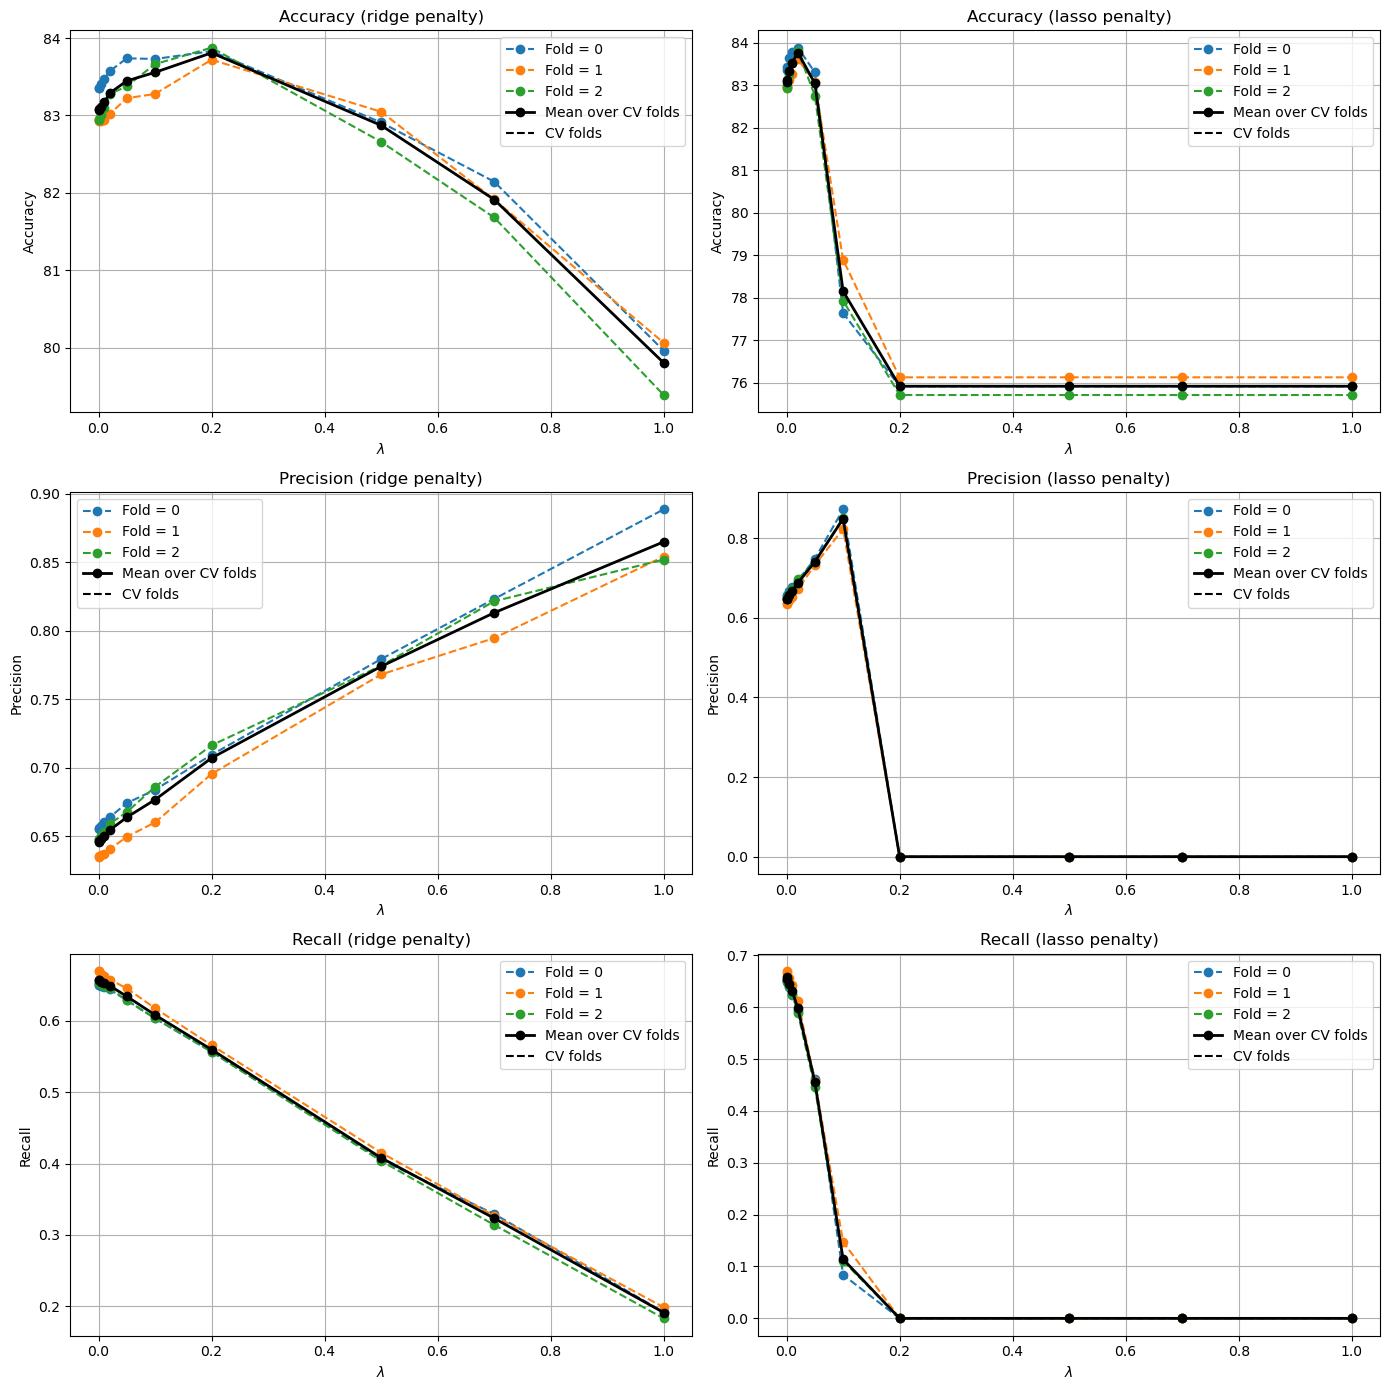

In [ ]:
penalties_to_plot = ["ridge","lasso"]
metric_data = [acc_by_fold, prec_by_fold, rec_by_fold]
metric_names = ["Accuracy","Precision","Recall"]

fig, axes = plt.subplots(3,2, figsize=(14,14))

for row in range(3):
    for col in range(2):
        penalty = penalties_to_plot[col]
        ax = axes[row,col]
        
        for i in range(len(metric_data[row][penalty])):
            ax.plot(lam,metric_data[row][penalty][i],ls='--', marker='o', label=f"Fold = {i}")
        
        mean_cv_metric = np.mean(np.array(metric_data[row][penalty]),axis=0)
        ax.plot(lam,mean_cv_metric, color='k', linewidth=2, marker='o', label='Mean over CV folds')
        ax.plot([],[],ls='--',color='k', label='CV folds')
        
        ax.set_xlabel(r'$\lambda$')
        ax.set_ylabel(metric_names[row])
        ax.set_title(f'{metric_names[row]} ({penalty} penalty)')
        ax.grid()
        ax.legend()
        
        best_l = lam[np.argmax(mean_cv_metric)]
        print(f"Best lambda value for {metric_names[row]} with {penalty} penalty (CV estimate): {best_l}")

plt.tight_layout()

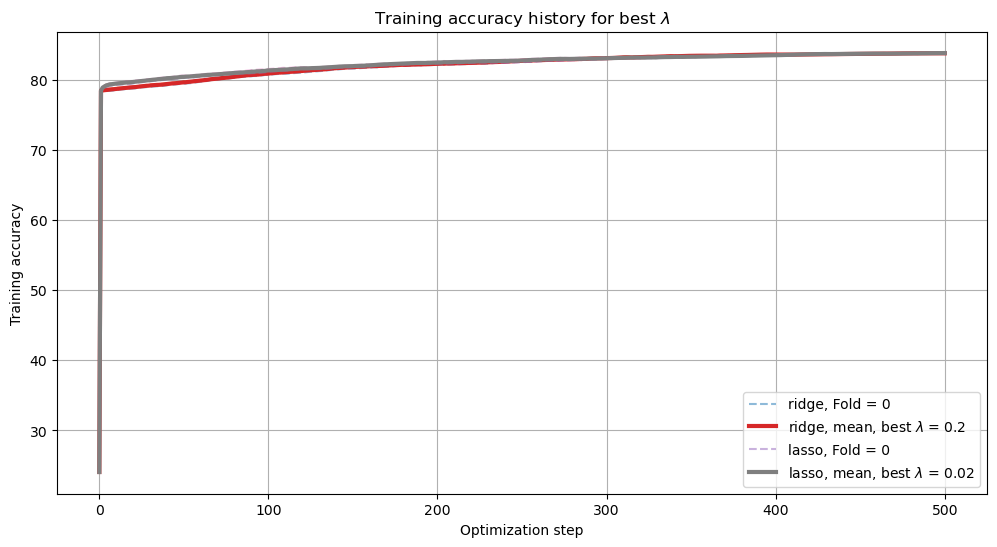

In [ ]:
penalties_to_plot = ["ridge","lasso"]

plt.figure(figsize=(12,6))

for penalty in penalties_to_plot:
    
    mean_cv_acc = np.mean(np.array(acc_by_fold[penalty]),axis=0)
    best_l_index = np.argmax(mean_cv_acc)
    best_l = lam[best_l_index]
    
    histories = []
    
    for i in range(len(metrics_history_by_fold[penalty])):
        history = metrics_history_by_fold[penalty][i][best_l_index]["accuracy"]
        histories.append(history)
        plt.plot(history, ls='--', alpha=0.5, label=f"{penalty}, Fold = {i}" if i == 0 else None)
    
    mean_history = np.mean(np.array(histories), axis=0)
    plt.plot(mean_history, linewidth=3, label=f"{penalty}, mean, best $\\lambda$ = {best_l}")

plt.xlabel('Optimization step')
plt.ylabel('Training accuracy')
plt.title('Training accuracy history for best $\\lambda$')
plt.grid()
plt.legend()

### Compare

## Discussion

### Why some features are better suited to non-one-hot encoding ✅

### How encoding affects model interpretability (via coefficients) ✅

### Tradeoffs between sparsity, performance, and leakage ✅